# 29b. Load Testing Inference Servers

**Tier:** Production & Safety
**Estimated time:** 55 minutes
**Prerequisites:** 13b (vLLM inference serving), 29 (serving LLM apps)
**Priority:** 🟡 Important — the one time you actually need this is a launch that goes badly. *If skipped, revisit when:* you're about to ship an LLM feature to real traffic and want to know its actual breaking point instead of finding out from users.
**Source material:** Schroeder & Harchol-Balter et al. on open-vs-closed system benchmarking; NVIDIA GenAI-Perf and the vLLM/SGLang benchmark suites (industry LLM-serving load-testing tools, 2026); Kwon et al.'s PagedAttention paper (notebook 13b) for the continuous-batching background these numbers build on.

## What You'll Learn
- The metrics vocabulary real LLM load tests report: **TTFT**, **TPOT/ITL**, **E2E latency**, and **goodput**
- Why sweeping **concurrency** against a real (mocked) streaming server produces a throughput/latency **knee** — the point where adding more simultaneous requests stops helping and starts hurting everyone
- The difference between **closed-loop** and **open-loop** load generation, and why a closed-loop test can look stable at a concurrency level that would collapse under genuinely independent (open) arrivals at the same rate
- What to actually run 1,000+ concurrent requests for, and what real tools (`genai-perf`, `k6`, the vLLM/SGLang bench suites) are built for instead of reinventing

## Why This Matters
Notebook 29 built a real FastAPI server and showed it handles a *handful* of concurrent requests without blocking. That's necessary but nowhere near sufficient — "doesn't block" and "survives 1,000 real users hitting it at once" are different claims, and the gap between them is exactly what load testing measures. This notebook builds a small, fully local mock of a saturating GPU server and puts a real load generator in front of it, so the throughput/latency curves you see are the *actual* output of an *actual* concurrent system, not a story about one.


## The metrics vocabulary

Every serious LLM load-testing report — from a `genai-perf` run against a real vLLM server to this notebook's mock — uses the same four numbers:

- **TTFT (time to first token):** wall-clock time from when a request is sent to when the *first* output token arrives. Dominated by queueing (waiting for a free GPU slot) plus prefill (processing the prompt). This is what users perceive as "did it start responding."
- **TPOT / ITL (time per output token / inter-token latency):** the average gap between *subsequent* tokens once generation has started. This is what users perceive as "is it streaming smoothly."
- **E2E (end-to-end) latency:** TTFT plus the sum of all inter-token gaps — the total time from request to final token. The number that actually determines "how long did the user wait."
- **Goodput:** the fraction of requests that meet a latency **SLO** (e.g. "TTFT under 500ms") — a single average or even a P99 can hide the fact that 30% of requests are unacceptable while the rest are fine; goodput doesn't.

Everything below measures the first three directly and lets you compute the fourth.


In [1]:
import os, sys, time, socket, subprocess, atexit, textwrap
from pathlib import Path

def find_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]

PORT = find_free_port()
APP_DIR = Path("/tmp/nb29b_app")
APP_DIR.mkdir(exist_ok=True)
print(f"Will run the mock server on port {PORT}")


Will run the mock server on port 48649


## A mock server that behaves like a saturating GPU

Real streaming inference has two costs: **prefill** (proportional to prompt length, gates the first token) and **decode** (one step per output token). A GPU can only run so many requests at once — vLLM's continuous batching (notebook 13b) keeps a fixed number of "slots" busy. We simulate exactly that shape with an `asyncio.Semaphore` standing in for GPU capacity: a request waits for a free slot, "prefills" for a fixed time, then streams tokens one at a time. Whatever queueing happens above that capacity shows up honestly in the client's measured TTFT — nothing is faked or shortcut.


In [2]:
APP_SOURCE = textwrap.dedent(r'''
    import asyncio, json, random, time
    from fastapi import FastAPI
    from fastapi.responses import StreamingResponse
    from pydantic import BaseModel

    app = FastAPI()

    BATCH_SLOTS = 16      # simulated GPU capacity -- only this many requests run at once
    TTFT_BASE_S = 0.03     # simulated prefill time once a slot is acquired
    TPOT_S = 0.012         # simulated per-token decode time
    N_TOKENS = 8           # simulated output length per request

    gpu_slots = asyncio.Semaphore(BATCH_SLOTS)

    class GenRequest(BaseModel):
        prompt: str = ""

    @app.get("/health")
    def health():
        return {"status": "ok"}

    def sse_line(payload):
        return "data: " + json.dumps(payload) + "\n\n"

    @app.post("/generate")
    async def generate(req: GenRequest):
        async def token_stream():
            # Waiting here for a free slot IS the queueing delay a real saturated
            # GPU would impose -- nothing about this is simulated after this point.
            async with gpu_slots:
                await asyncio.sleep(TTFT_BASE_S)
                yield sse_line({"token": ""})
                for i in range(N_TOKENS):
                    await asyncio.sleep(TPOT_S * random.uniform(0.8, 1.2))
                    yield sse_line({"token": f"tok{i}"})
            yield sse_line({"done": True})
        return StreamingResponse(token_stream(), media_type="text/event-stream")
''')
(APP_DIR / "app.py").write_text(APP_SOURCE)
print(f"Wrote mock server to {APP_DIR / 'app.py'}")


Wrote mock server to /tmp/nb29b_app/app.py


In [3]:
server_proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "app:app", "--host", "127.0.0.1", "--port", str(PORT), "--log-level", "warning"],
    cwd=str(APP_DIR), stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
atexit.register(server_proc.terminate)   # safety net if the explicit cleanup cell is skipped

def wait_for_health(port, timeout_s=15):
    import urllib.request
    deadline = time.time() + timeout_s
    while time.time() < deadline:
        try:
            urllib.request.urlopen(f"http://127.0.0.1:{port}/health", timeout=0.5)
            return True
        except Exception:
            time.sleep(0.3)
    return False

server_up = wait_for_health(PORT)
BASE_URL = f"http://127.0.0.1:{PORT}"
print(f"Server healthy: {server_up}")


Server healthy: True


## Closed-loop load generation: N workers, each firing its next request the instant the last one finishes

This is the standard way to characterize a server's capacity: hold a fixed number of clients (`concurrency`) alive, each looping request-after-request, and measure throughput and tail latency at each concurrency level. It's exactly what most published "max throughput" numbers measure, and it's a legitimate, useful test — you'll see why it isn't the *whole* story once we compare it against open-loop later.


In [4]:
import asyncio
import numpy as np
import httpx

async def _one_request(client, base_url):
    t0 = time.perf_counter()
    ttft = None
    async with client.stream("POST", f"{base_url}/generate", json={"prompt": "hi"}) as resp:
        async for line in resp.aiter_lines():
            if line.startswith("data:") and ttft is None:
                ttft = time.perf_counter() - t0
    e2e = time.perf_counter() - t0
    return ttft, e2e

async def closed_loop_load(base_url, concurrency, requests_per_worker=1):
    """`concurrency` workers, each firing its NEXT request only after its previous
    one completes -- so total in-flight requests never exceeds `concurrency`.
    """
    limits = httpx.Limits(max_connections=concurrency + 100, max_keepalive_connections=concurrency + 100)
    async with httpx.AsyncClient(timeout=60.0, limits=limits) as client:
        async def worker():
            return [await _one_request(client, base_url) for _ in range(requests_per_worker)]
        all_results = await asyncio.gather(*[worker() for _ in range(concurrency)])
    return [r for sub in all_results for r in sub]

# A quick sanity check at low concurrency before the full sweep.
sample = await closed_loop_load(BASE_URL, concurrency=4, requests_per_worker=2)
print(f"Sample: {len(sample)} requests, mean TTFT {np.mean([r[0] for r in sample])*1000:.1f}ms")


Sample: 8 requests, mean TTFT 35.6ms


## The concurrency sweep: finding the knee

Now the real test: sweep concurrency from 1 all the way past 1,000 — genuinely running that many simultaneous requests against the live server, not a projection — and watch throughput and tail latency as the server moves from underloaded to saturated to overloaded.


In [5]:
CONCURRENCY_LEVELS = [1, 8, 16, 32, 64, 128, 256, 512, 1024]
sweep = []
for c in CONCURRENCY_LEVELS:
    t0 = time.perf_counter()
    results = await closed_loop_load(BASE_URL, concurrency=c, requests_per_worker=1)
    wall = time.perf_counter() - t0
    ttfts = np.array([r[0] for r in results])
    e2es = np.array([r[1] for r in results])
    row = {
        "concurrency": c,
        "throughput": len(results) / wall,
        "ttft_p50": np.percentile(ttfts, 50) * 1000,
        "ttft_p99": np.percentile(ttfts, 99) * 1000,
        "e2e_p99": np.percentile(e2es, 99) * 1000,
    }
    sweep.append(row)
    print(f"concurrency={c:5d}  throughput={row['throughput']:7.1f} req/s  "
          f"TTFT p50={row['ttft_p50']:7.1f}ms  TTFT p99={row['ttft_p99']:7.1f}ms  "
          f"E2E p99={row['e2e_p99']:8.1f}ms")


concurrency=    1  throughput=    4.6 req/s  TTFT p50=   34.0ms  TTFT p99=   34.0ms  E2E p99=   133.4ms


concurrency=    8  throughput=   37.2 req/s  TTFT p50=   40.3ms  TTFT p99=   41.3ms  E2E p99=   143.6ms


concurrency=   16  throughput=   66.4 req/s  TTFT p50=   53.9ms  TTFT p99=   55.2ms  E2E p99=   159.5ms


concurrency=   32  throughput=   85.1 req/s  TTFT p50=  123.6ms  TTFT p99=  200.4ms  E2E p99=   300.8ms


concurrency=   64  throughput=   98.4 req/s  TTFT p50=  262.7ms  TTFT p99=  460.8ms  E2E p99=   559.8ms


concurrency=  128  throughput=  101.4 req/s  TTFT p50=  580.5ms  TTFT p99= 1024.1ms  E2E p99=  1138.3ms


concurrency=  256  throughput=   95.7 req/s  TTFT p50= 1292.9ms  TTFT p99= 2355.7ms  E2E p99=  2489.0ms


concurrency=  512  throughput=   63.4 req/s  TTFT p50= 3196.0ms  TTFT p99= 5852.5ms  E2E p99=  7878.9ms


concurrency= 1024  throughput=   76.3 req/s  TTFT p50= 7684.1ms  TTFT p99=11715.7ms  E2E p99= 13210.6ms


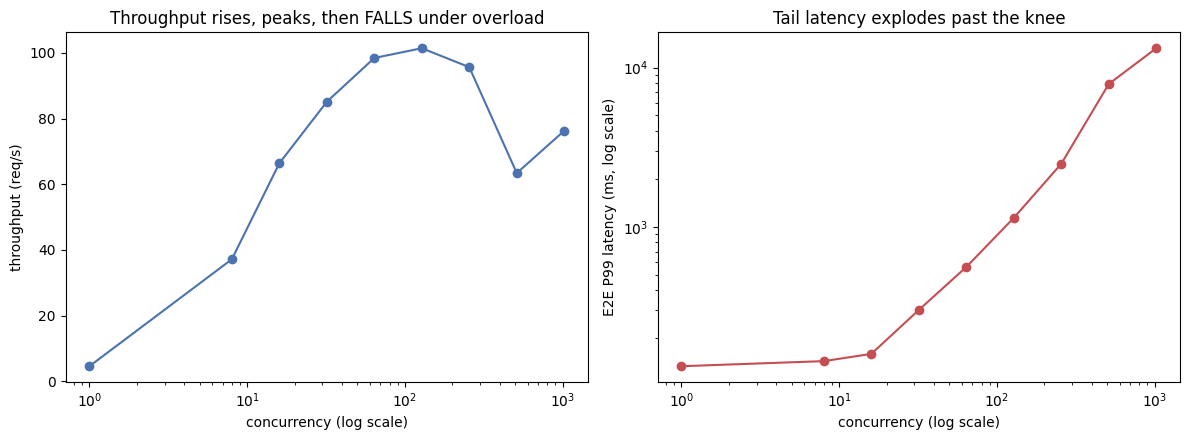

Best throughput: 101.4 req/s at concurrency=128 (P99 there: 1138ms)


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

concurrencies = [r["concurrency"] for r in sweep]
throughputs = [r["throughput"] for r in sweep]
p99s = [r["e2e_p99"] for r in sweep]

ax1.plot(concurrencies, throughputs, marker="o", color="#4C72B0")
ax1.set_xscale("log"); ax1.set_xlabel("concurrency (log scale)")
ax1.set_ylabel("throughput (req/s)")
ax1.set_title("Throughput rises, peaks, then FALLS under overload")

ax2.plot(concurrencies, p99s, marker="o", color="#C44E52")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("concurrency (log scale)"); ax2.set_ylabel("E2E P99 latency (ms, log scale)")
ax2.set_title("Tail latency explodes past the knee")

plt.tight_layout(); plt.show()

knee = max(sweep, key=lambda r: r["throughput"])
print(f"Best throughput: {knee['throughput']:.1f} req/s at concurrency={knee['concurrency']} "
      f"(P99 there: {knee['e2e_p99']:.0f}ms)")


*Throughput climbs as concurrency grows from 1 toward the server's real capacity (16 GPU slots), peaks somewhere in the dozens-to-low-hundreds, and then actually FALLS as even more requests pile up competing for the same 16 slots — pure queueing overhead with no more useful work getting done. Tail latency doesn't wait for the peak: it's already climbing steeply well before throughput tops out, and by concurrency=1024 a request can wait upwards of ten seconds just to start.*

This is the "knee" every real capacity-planning conversation is trying to find: the concurrency level where you get the most throughput without tail latency becoming unacceptable — usually well *before* the point where throughput itself peaks.

## What a closed-loop sweep can't show you

Every number above came from **closed-loop** load: exactly `concurrency` requests in flight, ever, by construction. That's a perfectly good way to answer "how does the server behave with exactly N simultaneous users each waiting their turn" — but real internet traffic doesn't wait its turn. A genuinely **open-loop** load generator fires new requests at a target rate on a fixed schedule (a Poisson process, matching real independent user arrivals), *regardless* of whether earlier requests have finished yet. If the target rate exceeds what the server can sustain, the backlog of waiting requests **grows without bound** — latency doesn't level off at some high-but-finite number the way closed-loop's did at concurrency=1024, it keeps climbing for as long as the overload continues, because nothing in an open system caps how many requests can be waiting at once.

That's a failure mode a closed-loop sweep can *never* produce, no matter how high you push concurrency — a closed system is mechanically incapable of having more requests in flight than its concurrency setting, so it always eventually settles into *some* steady, bounded latency for that setting. Real tools built for this — **NVIDIA GenAI-Perf**, **k6**, and the benchmark scripts vLLM and SGLang ship themselves — default to open-loop generation for exactly this reason, even though closed-loop concurrency sweeps (like the one above) remain the standard way to characterize a server's raw throughput ceiling.

## Exercises


In [7]:
# Exercise 1 (Warm-up): How much does GPU capacity change the knee?
# Task: Edit APP_SOURCE to set BATCH_SLOTS = 4 (a much smaller "GPU"), rewrite app.py,
#       restart the server (terminate server_proc, relaunch subprocess.Popen with the same
#       command, wait_for_health again), then re-run the concurrency sweep at just
#       [1, 4, 8, 16, 32, 64] concurrency levels. Where does the throughput knee move to?
# Hint: BATCH_SLOTS is baked into APP_SOURCE as a literal string -- edit the string itself
#       (str.replace("BATCH_SLOTS = 16", "BATCH_SLOTS = 4")) before rewriting app.py.

# YOUR CODE HERE


In [8]:
# Exercise 2 (Apply): Implement the open-loop Poisson arrival generator
# Task: Write open_loop_load(base_url, target_rate_per_sec, duration_s) that schedules
#       requests at Poisson-distributed arrival times over duration_s (independent of
#       when earlier requests finish -- NOT a loop of "await response, then send next").
#       Run it TWICE against the running server: once at a rate below the throughput knee
#       (e.g. 60/s) and once clearly above it (e.g. 150/s). For the above-capacity run,
#       bucket requests by send time into 8-10 groups and print mean E2E latency per
#       bucket -- confirm it GROWS over the run's duration, while the below-capacity run's
#       bucketed latency stays roughly flat.
# Hint: Generate arrival times via a running sum of np.random.default_rng().exponential(
#       1/target_rate_per_sec); asyncio.create_task() a coroutine per arrival that sleeps
#       until its scheduled time, then makes the request; asyncio.gather() them all.

# YOUR CODE HERE


In [9]:
# Exercise 3 (Extend): Connect this to real observability and autoscaling
# Task: Using the sweep data already collected, compute "goodput" at each concurrency
#       level against an SLO of TTFT < 300ms (goodput = fraction of requests meeting the
#       SLO -- you'll need to keep per-request TTFTs, not just the P99, so rerun
#       closed_loop_load at 2-3 concurrency levels and compute the fraction under 300ms
#       directly). At what concurrency does goodput fall below 90%? Compare that number to
#       the "best throughput" concurrency printed after the sweep plot -- are they the same
#       point? Note this goodput number for later: notebook 29c turns it into a real
#       Prometheus metric, and 29d's autoscaler decides WHEN to add capacity using exactly
#       this kind of signal instead of raw CPU usage.
# Hint: fraction = np.mean(np.array(ttfts) < 0.3) after running closed_loop_load and
#       collecting the raw per-request ttft values (not just the percentile summary).

# YOUR CODE HERE


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
small_gpu_source = APP_SOURCE.replace("BATCH_SLOTS = 16", "BATCH_SLOTS = 4")
(APP_DIR / "app.py").write_text(small_gpu_source)
server_proc.terminate(); server_proc.wait(timeout=5)
server_proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "app:app", "--host", "127.0.0.1", "--port", str(PORT), "--log-level", "warning"],
    cwd=str(APP_DIR), stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
wait_for_health(PORT)
for c in [1, 4, 8, 16, 32, 64]:
    t0 = time.perf_counter()
    results = await closed_loop_load(BASE_URL, concurrency=c, requests_per_worker=1)
    wall = time.perf_counter() - t0
    print(f"concurrency={c:3d}  throughput={len(results)/wall:6.1f} req/s")
# With only 4 GPU slots instead of 16, the knee arrives at a proportionally lower
# concurrency -- capacity is a property of the SERVER, not of how many clients show up.

# Exercise 2
async def open_loop_load(base_url, target_rate_per_sec, duration_s, seed=0):
    rng = np.random.default_rng(seed)
    limits = httpx.Limits(max_connections=3000, max_keepalive_connections=3000)
    results = []
    start = time.perf_counter()
    async with httpx.AsyncClient(timeout=120.0, limits=limits) as client:
        async def fire(send_time):
            await asyncio.sleep(max(0, send_time - (time.perf_counter() - start)))
            try:
                ttft, e2e = await _one_request(client, base_url)
                results.append((send_time, ttft, e2e))
            except Exception:
                results.append((send_time, None, None))
        tasks, t = [], 0.0
        while t < duration_s:
            t += rng.exponential(1.0 / target_rate_per_sec)
            if t >= duration_s:
                break
            tasks.append(asyncio.create_task(fire(t)))
        await asyncio.gather(*tasks)
    return [r for r in results if r[2] is not None]

def show_latency_over_time(results, n_buckets=8):
    results = sorted(results, key=lambda r: r[0])
    bucket = max(1, len(results) // n_buckets)
    for i in range(0, len(results), bucket):
        chunk = results[i:i + bucket]
        send_times = [c[0] for c in chunk]
        e2es = [c[2] for c in chunk]
        print(f"send_time [{min(send_times):5.1f}s-{max(send_times):5.1f}s]  "
              f"mean E2E {np.mean(e2es)*1000:8.1f}ms")

print("--- below capacity (60/s) ---")
below = await open_loop_load(BASE_URL, target_rate_per_sec=60, duration_s=10.0)
show_latency_over_time(below)

print("--- above capacity (150/s) ---")
above = await open_loop_load(BASE_URL, target_rate_per_sec=150, duration_s=20.0)
show_latency_over_time(above)
# Below capacity, mean E2E per time bucket stays roughly flat -- the queue reaches a
# stable size. Above capacity, mean E2E climbs bucket over bucket without leveling off
# -- the backlog is growing for as long as arrivals keep outpacing service, which is
# exactly the unbounded-queue behavior closed-loop testing structurally cannot produce.

# Exercise 3
SLO_S = 0.3
for c in [64, 128, 256]:
    results = await closed_loop_load(BASE_URL, concurrency=c, requests_per_worker=2)
    ttfts = np.array([r[0] for r in results])
    goodput = np.mean(ttfts < SLO_S)
    print(f"concurrency={c:4d}  goodput (TTFT<300ms) = {goodput:.1%}")
# Goodput typically crosses below 90% at a LOWER concurrency than where raw throughput
# peaks -- the "best throughput" point already has a meaningful fraction of unhappy
# requests. This is why goodput (or an SLO-aware percentile), not peak throughput, is
# the number that should actually drive an autoscaling decision (notebook 29d) or a
# paging alert (notebook 29c).
```
</details>


In [10]:
# Cleanup -- always terminate a server you started.
server_proc.terminate()
try:
    server_proc.wait(timeout=5)
except subprocess.TimeoutExpired:
    server_proc.kill()
print("Server terminated.")


Server terminated.


## Key Takeaways
- Every LLM load test reports the same four numbers: **TTFT** (queueing + prefill), **TPOT/ITL** (per-token streaming smoothness), **E2E latency** (the number users feel), and **goodput** (fraction meeting an SLO — often more honest than a bare percentile).
- Sweeping concurrency against a real server reveals a **knee**: throughput rises, peaks, then *falls* as requests pile up competing for the same fixed capacity, while tail latency climbs well before the peak — the knee, not the peak, is usually where you actually want to operate.
- **Closed-loop** load (N workers, each firing its next request only after the last completes) is the standard way to find that knee, but it structurally caps in-flight requests at `concurrency` — it can never show you a queue that grows without bound.
- **Open-loop** load (Poisson arrivals at a fixed target rate, independent of completions) is what real traffic looks like, and it's the only way to see genuine overload: past capacity, latency climbs continuously for as long as the overload lasts, instead of settling at some high-but-bounded number.
- Real tools (GenAI-Perf, k6, vLLM/SGLang's own bench scripts) default to open-loop generation for exactly this reason — this notebook's simulators are a from-scratch version of the same idea, not a replacement for them on a real server.

## What's Next
Notebook **29c — Inference Observability** takes the same mock server and instruments it with real Prometheus metrics, so instead of printing sweep results by hand you scrape a `/metrics` endpoint and compute the same TTFT/goodput numbers the way a production dashboard actually would.
